<a href="https://colab.research.google.com/github/pushkershukla/InsightFace-PyTorch/blob/master/Combining_LiMe_and_TCAV_TIGER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install captum
#! pip install google_images_download
# Current Change :- The zebra img is changed for stripes folder

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.4 MB 28.7 MB/s 


In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [3]:
import numpy as np
import os, glob

import matplotlib.pyplot as plt

from PIL import Image

from scipy.stats import ttest_ind
#from google_images_download import google_images_download 
# ..........torch imports............
import torch
import torchvision

from torch.utils.data import IterableDataset, DataLoader,Dataset
from torchvision import transforms

#.... Captum imports..................
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients

from captum.concept import TCAV
from captum.concept import Concept

from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str
import shutil

In [4]:
# Method to normalize an image to Imagenet mean and standard deviation


def transform(img):

 
    return transforms.Compose(
          [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
          ]
      )(img)
def transform_np(img):
    #print(img.shape)  
    return transforms.Compose(
          [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            #transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
          ]
      )(img)


In [5]:
def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("RGB")
    return transform(img)


def load_image_tensors(class_name, root_path="/content/gdrive/MyDrive/interpretability_exp/", transform=True):
    path = os.path.join(root_path, class_name)
    filenames = glob.glob(path + '/*.jpg')

    tensors = []
    for filename in filenames:
        img = Image.open(filename).convert('RGB')
        #img=io.imread(filename)
        tensors.append(transform(img) if transform else img)
    
    return tensors


In [6]:
def assemble_concept(name, id, concepts_path="/"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concepts_path)
    concept_iter = dataset_to_dataloader(dataset)

    return Concept(id=id, name=name, data_iter=concept_iter)

In [7]:
#! wget /content/gdrive/MyDrive/hymenoptera_data/ http://netdissect.csail.mit.edu/data/broden1_224.zip
#!curl -O /content/gdrive/MyDrive/interpretability_exp http://netdissect.csail.mit.edu/data/broden1_224.zip
#! wget -O /content/gdrive/MyDrive/interpretability_exp/broden1_224.zip http://netdissect.csail.mit.edu/data/broden1_224.zip
#!unzip -qq broden1_224.zip -d /content/gdrive/MyDrive/interpretability_exp
#!unzip /content/gdrive/MyDrive/interpretability_exp/broden1_224.zip 
#!rm broden1_224.zip

In [8]:
concepts_path    = '/content/gdrive/MyDrive/interpretability_exp/broden1_224/images/dtd/'

random_img_folder = '/content/gdrive/MyDrive/interpretability_exp/'
print(os.listdir(random_img_folder))
texture_concepts = ['zigzagged', 'striped', 'dotted']
#random_concepts=['random_0','random_1']
#textures = {texture: load_texture(texture) for texture in to_load}
#def _load
'''
def create_random_set(id_no,folder=random_img_folder,set_length=120):
    file_list=os.listdir(folder)
    file_list=file_list[id_no*set_length:(id_no+1)*set_length]
    dir_path=os.path.join(folder,"random_"+str(id_no))
    print(dir_path)
    print(file_list)
    try: 
        dir_path =os.mkdir(dir_path) 
        print("Created the direcotry "+dir_path)
    except OSError as error: 

        print("Directory " +dir_path +" already exsists")
    for file in file_list:
      print(file)
      try:
        shutil.copy(files, dir_path)
        #print("Successfuly copied "+ file+ " to "+ dir_path)
      except shutil.SameFileError:
        print("Source and destination represents the same file.")
 

      except PermissionError:
          print("Permission denied.")
      except:
          print("Error occurred while copying file.")
    return {"random_"+str(id_no):dir_path}


def get_files(texture,folder_path):
  textures_files = os.listdir(folder_path)
  files = [folder_path + t for t in textures_files if texture in t]
  return files
def create_folders(concepts_path,to_load):
  dir_path=""
  concept_folders={}
  for t in to_load:
    dir_path=os.path.join(concepts_path,t)
    #print("Files", os.listdir(dir_path))
    #print("Directory =", dir_path)
    concept_folders.update({t:dir_path})
    #concept_folders=concept_folders.append(dir_path)
    try: 
        os.mkdir(dir_path) 
        print("Created the direcotry "+dir_path)
    except OSError as error: 

        print("Directory " +dir_path +" already exsists") 
    concept_imgs=get_files(t,concepts_path)
    for files in concept_imgs:
      print(files)
      try:
        shutil.copy(files, dir_path)
        #print("Successfuly copied "+ files+ " to "+ dir_path)
      except shutil.SameFileError:
        print("Source and destination represents the same file.")
 

      except PermissionError:
          print("Permission denied.")
      except:
          print("Error occurred while copying file.")
  return concept_folders
concept_folders= create_folders(concepts_path,texture_concepts)
#random_concepts=create_folders(random_img_folder,random_concepts)
#print(random_concepts)
#print(get_files('striped',concepts_path))
stripes_concept = assemble_concept("striped", 0, concept_folders["striped"])
#print(stripes_concept)
zigzagged_concept = assemble_concept("zigzagged", 1, concept_folders["zigzagged"])
dotted_concept = assemble_concept("dotted", 2, concept_folders["dotted"])

#print(random_0_concept)
'''
'''
input_size = 299

textures_files = os.listdir(texture_folder)
textures_availables = np.unique([t.split('_')[0] for t in textures_files])
print('The Texture available are : \n-', '\n- '.join(textures_availables))
'''


['broden1_224.zip', 'dtd', 'broden1_224', 'zebra', 'random_0', 'random_1', 'results', 'results.png', 'grasslands', 'indoor', 'stripes_extra']


"\ninput_size = 299\n\ntextures_files = os.listdir(texture_folder)\ntextures_availables = np.unique([t.split('_')[0] for t in textures_files])\nprint('The Texture available are : \n-', '\n- '.join(textures_availables))\n"

In [9]:
from skimage import io
class concept_dataset(Dataset):
  def __init__(self,input_dir,transform=None):
    self.filenames=glob.glob(input_dir+'/*.jpg')
    self.transform=transform
  def __getitem__(self,idx):
    img = Image.open(self.filenames[idx]).convert('RGB')
    #img=io.imread(self.filenames[idx])
    if self.transform is not None:
      img=self.transform(img)
    return img
  def __len__(self):
    return(len(self.filenames))
striped_folder ='/content/gdrive/MyDrive/interpretability_exp/broden1_224/images/dtd/striped'
striped_dataset=concept_dataset(striped_folder, transform=transform)
striped_dataloader=DataLoader(striped_dataset)
random_0_folder='/content/gdrive/MyDrive/interpretability_exp/random_0'
random_0_dataset=concept_dataset(random_0_folder, transform=transform)
random_0_dataloader=DataLoader(random_0_dataset)
random_1_folder='/content/gdrive/MyDrive/interpretability_exp/random_1'
random_1_dataset=concept_dataset(random_1_folder, transform=transform)
random_1_dataloader=DataLoader(random_1_dataset)
'''
for imgs in random_0_dataloader:
    print("Batch of images has shape: ",imgs.shape)

'''


'\nfor imgs in random_0_dataloader:\n    print("Batch of images has shape: ",imgs.shape)\n\n'

In [10]:
'''
random_concepts={"random_0":"/content/gdrive/MyDrive/interpretability_exp/random_0",
                 "random_1":"/content/gdrive/MyDrive/interpretability_exp/random_1"}

random_0_concept = assemble_concept("random_0", 3, random_concepts["random_0"])
random_1_concept = assemble_concept("random_1", 4, random_concepts["random_1"])
'''

'\nrandom_concepts={"random_0":"/content/gdrive/MyDrive/interpretability_exp/random_0",\n                 "random_1":"/content/gdrive/MyDrive/interpretability_exp/random_1"}\n\nrandom_0_concept = assemble_concept("random_0", 3, random_concepts["random_0"])\nrandom_1_concept = assemble_concept("random_1", 4, random_concepts["random_1"])\n'

In [11]:
! ls "/content/gdrive/MyDrive/interpretability_exp/"

broden1_224	 dtd	     indoor    random_1  results.png	zebra
broden1_224.zip  grasslands  random_0  results	 stripes_extra


In [12]:
'''

n_figs = 7
n_concepts = 5

fig, axs = plt.subplots(n_concepts, n_figs + 1, figsize = (25, 4 * n_concepts))

for c, concept in enumerate([stripes_concept, zigzagged_concept, dotted_concept,random_0_concept,random_1_concept]):
    concept_path = os.path.join(concepts_path, concept.name) + "/"
    img_files = glob.glob(concept_path + '*')
    for i, img_file in enumerate(img_files[:n_figs + 1]):
        if os.path.isfile(img_file):
            if i == 0:
                axs[c, i].text(1.0, 0.5, str(concept.name), ha='right', va='center', family='sans-serif', size=24)
            else:
                img = plt.imread(img_file)
                axs[c, i].imshow(img)

            axs[c, i].axis('off')
'''

'\n\nn_figs = 7\nn_concepts = 5\n\nfig, axs = plt.subplots(n_concepts, n_figs + 1, figsize = (25, 4 * n_concepts))\n\nfor c, concept in enumerate([stripes_concept, zigzagged_concept, dotted_concept,random_0_concept,random_1_concept]):\n    concept_path = os.path.join(concepts_path, concept.name) + "/"\n    img_files = glob.glob(concept_path + \'*\')\n    for i, img_file in enumerate(img_files[:n_figs + 1]):\n        if os.path.isfile(img_file):\n            if i == 0:\n                axs[c, i].text(1.0, 0.5, str(concept.name), ha=\'right\', va=\'center\', family=\'sans-serif\', size=24)\n            else:\n                img = plt.imread(img_file)\n                axs[c, i].imshow(img)\n\n            axs[c, i].axis(\'off\')\n'

In [13]:
# Ignore all the concepts above
stripes_concept=Concept(0,"stripes",striped_dataloader)
random_0_concept=Concept(1,"random_0",random_0_dataloader)
random_1_concept=Concept(2,"random_1",random_1_dataloader)




In [14]:
'''
for c, concept in enumerate([stripes_concept,random_0_concept]):
    concept_path = os.path.join(concepts_path, concept.name) + "/"
    img_files = glob.glob(concept_path + '*')
    print(img_files)
'''

'\nfor c, concept in enumerate([stripes_concept,random_0_concept]):\n    concept_path = os.path.join(concepts_path, concept.name) + "/"\n    img_files = glob.glob(concept_path + \'*\')\n    print(img_files)\n'

In [15]:
!ls broden1_224/images/pascal/random_3

ls: cannot access 'broden1_224/images/pascal/random_3': No such file or directory


In [16]:
model = torchvision.models.googlenet(pretrained=True)
model = model.eval()

/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


  0%|          | 0.00/49.7M [00:00<?, ?B/s]

In [17]:
print(model)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [18]:
mytcav = TCAV(model=model,
layers=['inception4c', 'inception4d','inception4e'])

/usr/local/lib/python3.7/dist-packages/captum/concept/_utils/classifier.py:131: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  "Using default classifier for TCAV which keeps input"


In [19]:
'''
layers=['inception4c']#, 'inception4d', 'inception4e']

mytcav = TCAV(model=model,
              layers=layers,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))
                '''

"\nlayers=['inception4c']#, 'inception4d', 'inception4e']\n\nmytcav = TCAV(model=model,\n              layers=layers,\n              layer_attr_method = LayerIntegratedGradients(\n                model, None, multiply_by_inputs=False))\n                "

In [20]:
experimental_set_rand = [[random_0_concept,stripes_concept],[stripes_concept,random_1_concept]]

In [21]:
! ls broden1_224/images/dtd/zebra

ls: cannot access 'broden1_224/images/dtd/zebra': No such file or directory


In [22]:
# Load sample images from folder
zebra_imgs = load_image_tensors('stripes_extra', transform=False)

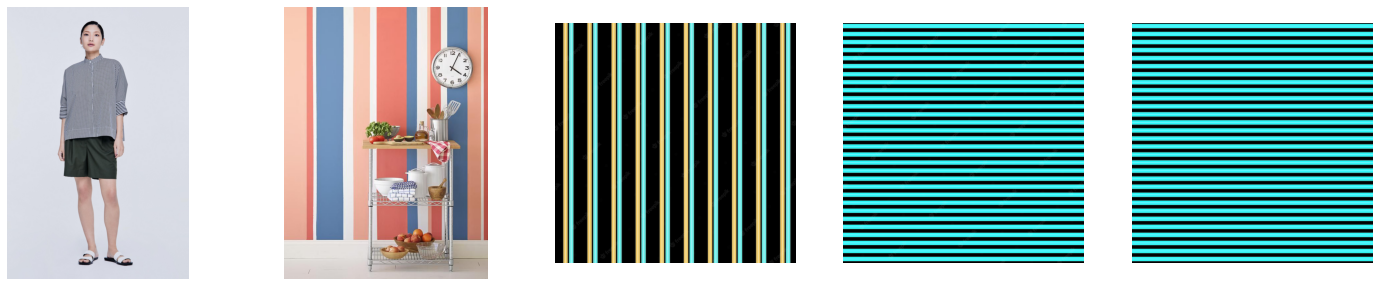

<class 'list'>
<class 'PIL.Image.Image'>


In [23]:
fig, axs = plt.subplots(1, 5, figsize = (25, 5))
axs[0].imshow(zebra_imgs[40])
axs[1].imshow(zebra_imgs[41])
axs[2].imshow(np.asarray(zebra_imgs[34]))
axs[3].imshow(zebra_imgs[31])
axs[4].imshow(zebra_imgs[30])

axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[3].axis('off')
axs[4].axis('off')

plt.show()
a=[5]
print(type(a))
print(type(zebra_imgs[34]))

In [24]:
print(type(zebra_imgs[0]))
zebra_tensors = torch.stack([transform(img) for img in zebra_imgs])
#experimental_set_rand


<class 'PIL.Image.Image'>


In [25]:
# zebra class index
zebra_ind = 340


#tcav_scores_w_random = mytcav.interpret(inputs=zebra_tensors,
                                        #experimental_sets=experimental_set_rand,
                                        #target=zebra_ind,
                        
                                       #)
#tcav_scores_w_random

In [26]:
! pip install lime

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 275 kB 28.9 MB/s 
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283857 sha256=c9d0cea644ddd2c8a5aa71e6053aadd7b4caeb24195b747ca17b32b88130e613
  Stored in directory: /root/.cache/pip/wheels/ca/cb/e5/ac701e12d365a08917bf4c6171c0961bc880a8181359c66aa7
Successfully built lime


In [27]:
from lime.wrappers.scikit_image import SegmentationAlgorithm
from lime import lime_image

In [28]:
explainer = lime_image.LimeImageExplainer(verbose = False)
segmenter = SegmentationAlgorithm('slic', n_segments=100, compactness=1, sigma=1)

In [29]:
#!/usr/bin/env python3

from collections import defaultdict
from typing import Any, cast, Dict, List, Set, Tuple, Union

import numpy as np
import torch
import torch.multiprocessing as multiprocessing
from captum._utils.av import AV
from captum._utils.common import _format_tensor_into_tuples, _get_module_from_name
from captum._utils.typing import TargetType, TensorOrTupleOfTensorsGeneric
from captum.attr import LayerActivation, LayerAttribution, LayerGradientXActivation
from captum.concept._core.cav import CAV
from captum.concept._core.concept import Concept, ConceptInterpreter
from captum.concept._utils.classifier import Classifier, DefaultClassifier
from captum.concept._utils.common import concepts_to_str
from captum.log import log_usage
from torch import Tensor
from torch.nn import Module
from torch.utils.data import DataLoader, Dataset


class LabelledDataset2(Dataset):
    """
    A torch Dataset whose __getitem__ returns both a batch of activation vectors,
    as well as a batch of labels associated with those activation vectors.
    It is used to train a classifier in train_tcav
    """

    def __init__(self, datasets: List[AV.AVDataset], labels: List[int]) -> None:
        """
        Creates the LabelledDataset given a list of K Datasets, and a length K
        list of integer labels representing K different concepts.
        The assumption is that the k-th Dataset of datasets is associated with
        the k-th element of labels.
        The LabelledDataset is the concatenation of the K Datasets in datasets.
        However, __get_item__ not only returns a batch of activation vectors,
        but also a batch of labels indicating which concept that batch of
        activation vectors is associated with.

        Args:

            datasets (list[Dataset]): The k-th element of datasets is a Dataset
                    representing activation vectors associated with the k-th
                    concept
            labels (list[int]): The k-th element of labels is the integer label
                    associated with the k-th concept
        """
        assert len(datasets) == len(
            labels
        ), "number of datasets does not match the number of concepts"

        from itertools import accumulate

        offsets = [0] + list(accumulate(map(len, datasets), (lambda x, y: x + y)))
        self.length = offsets[-1]
        self.datasets = datasets
        self.labels = labels
        self.lowers = offsets[:-1]
        self.uppers = offsets[1:]

    def _i_to_k(self, i):

        left, right = 0, len(self.uppers)
        while left < right:
            mid = (left + right) // 2
            if self.lowers[mid] <= i and i < self.uppers[mid]:
                return mid
            if i >= self.uppers[mid]:
                left = mid
            else:
                right = mid

    def __getitem__(self, i: int):
        """
        Returns a batch of activation vectors, as well as a batch of labels
        indicating which concept the batch of activation vectors is associated
        with.

        Args:

            i (int): which (activation vector, label) batch in the dataset to
                    return
        Returns:
            inputs (Tensor): i-th batch in Dataset (representing activation
                    vectors)
            labels (Tensor): labels of i-th batch in Dataset
        """
        assert i < self.length
        k = self._i_to_k(i)
        inputs = self.datasets[k][i - self.lowers[k]]
        assert len(inputs.shape) == 2

        labels = torch.tensor([self.labels[k]] * inputs.size(0), device=inputs.device)
        return inputs, labels

    def __len__(self) -> int:
        """
        returns the total number of batches in the labelled_dataset
        """
        return self.length


def train_cav2(
    model_id,
    concepts: List[Concept],
    layers: Union[str, List[str]],
    classifier: Classifier,
    save_path: str,
    classifier_kwargs: Dict,
) -> Dict[str, Dict[str, CAV]]:
    r"""
    A helper function for parallel CAV computations that can be called
    from a python process.

    Please see the TCAV class documentation for further information.

    Args:

        model_id (str): A unique identifier for the PyTorch model for which
                we would like to load the layer activations and train a
                model in order to compute CAVs.
        concepts (list[Concept]): A list of Concept objects that are used
                to train a classifier and learn decision boundaries between
                those concepts for each layer defined in the `layers`
                argument.
        layers (str or list[str]): A list of layer names or a single layer
                name that is used to compute the activations of all concept
                examples per concept and train a classifier using those
                activations.
        classifier (Classifier): A custom classifier class, such as the
                Sklearn "linear_model" that allows us to train a model
                using the activation vectors extracted for a layer per concept.
                It also allows us to access trained weights of the classifier
                and the list of prediction classes.
        save_path (str): The path for storing Concept Activation
                Vectors (CAVs) and Activation Vectors (AVs).
        classifier_kwargs (dict): Additional named arguments that are passed to
                concept classifier's `train_and_eval` method.

    Returns:
        cavs (dict): A dictionary of CAV objects indexed by concept ids and
                layer names. It gives access to the weights of each concept
                in a given layer and model statistics such as accuracies
                that resulted in trained concept weights.
    """

    concepts_key = concepts_to_str(concepts)
    cavs: Dict[str, Dict[str, CAV]] = defaultdict()
    cavs[concepts_key] = defaultdict()
    layers = [layers] if isinstance(layers, str) else layers
    for layer in layers:

        # Create data loader to initialize the trainer.
        datasets = [
            AV.load(save_path, model_id, concept.identifier, layer)
            for concept in concepts
        ]

        labels = [concept.id for concept in concepts]

        labelled_dataset = LabelledDataset2(cast(List[AV.AVDataset], datasets), labels)

        def batch_collate(batch):
            inputs, labels = zip(*batch)
            return torch.cat(inputs), torch.cat(labels)

        dataloader = DataLoader(labelled_dataset, collate_fn=batch_collate)

        classifier_stats_dict = classifier.train_and_eval(
            dataloader, **classifier_kwargs
        )
        classifier_stats_dict = (
            {} if classifier_stats_dict is None else classifier_stats_dict
        )

        weights = classifier.weights()
        assert (
            weights is not None and len(weights) > 0
        ), "Model weights connot be None or empty"

        classes = classifier.classes()
        assert (
            classes is not None and len(classes) > 0
        ), "Classes cannot be None or empty"

        classes = (
            cast(torch.Tensor, classes).detach().numpy()
            if isinstance(classes, torch.Tensor)
            else classes
        )
        cavs[concepts_key][layer] = CAV(
            concepts,
            layer,
            {"weights": weights, "classes": classes, **classifier_stats_dict},
            save_path,
            model_id,
        )
        # Saving cavs on the disk
        cavs[concepts_key][layer].save()

    return cavs


class TCAV2(ConceptInterpreter):
    '''
    Things Changed:-It also returns the individual scores along wth the 
    TCAV vectors for the entire datasrt
    '''
    """
    This class implements ConceptInterpreter abstract class using an
    approach called Testing with Concept Activation Vectors (TCAVs),
    as described in the paper:
    https://arxiv.org/abs/1711.11279

    TCAV scores for a given layer, a list of concepts and input example
    are computed using the dot product between prediction's layer
    sensitivities for given input examples and Concept Activation Vectors
    (CAVs) in that same layer.

    CAVs are defined as vectors that are orthogonal to the classification boundary
    hyperplane that separate given concepts in a given layer from each other.
    For a given layer, CAVs are computed by training a classifier that uses the
    layer activation vectors for a set of concept examples as input examples and
    concept ids as corresponding input labels. Trained weights of
    that classifier represent CAVs.

    CAVs are represented as a learned weight matrix with the dimensionality
    C X F, where:
    F represents the number of input features in the classifier.
    C is the number of concepts used for the classification. Concept
    ids are used as labels for concept examples during the training.

    We can use any layer attribution algorithm to compute layer sensitivities
    of a model prediction.
    For example, the gradients of an output prediction w.r.t. the outputs of
    the layer.
    The CAVs and the Sensitivities (SENS) are used to compute the TCAV score:

    0. TCAV = CAV • SENS, a dot product between those two vectors

    The final TCAV score can be computed by aggregating the TCAV scores
    for each input concept based on the sign or magnitude of the tcav scores.

    1. sign_count_score = | TCAV > 0 | / | TCAV |
    2. magnitude_score = SUM(ABS(TCAV * (TCAV > 0))) / SUM(ABS(TCAV))
    """

    def __init__(
        self,
        model: Module,
        layers: Union[str, List[str]],
        model_id: str = "default_model_id",
        classifier: Classifier = None,
        layer_attr_method: LayerAttribution = None,
        attribute_to_layer_input=False,
        save_path: str = "./cav/",
        **classifier_kwargs: Any,
    ) -> None:
        """
        Args:

            model (Module): An instance of pytorch model that is used to compute
                    layer activations and attributions.
            layers (str or list[str]): A list of layer name(s) that are
                    used for computing concept activations (cavs) and layer
                    attributions.
            model_id (str, optional): A unique identifier for the PyTorch `model`
                    passed as first argument to the constructor of TCAV class. It
                    is used to store and load activations for given input `model`
                    and associated `layers`.
            classifier (Classifier, optional): A custom classifier class, such as the
                    Sklearn "linear_model" that allows us to train a model
                    using the activation vectors extracted for a layer per concept.
                    It also allows us to access trained weights of the model
                    and the list of prediction classes.
            layer_attr_method (LayerAttribution, optional): An instance of a layer
                    attribution algorithm that helps us to compute model prediction
                    sensitivity scores.

                    Default: None
                    If `layer_attr_method` is None, we default it to gradients
                    for the layers using `LayerGradientXActivation` layer
                    attribution algorithm.
            save_path (str, optional): The path for storing CAVs and
                    Activation Vectors (AVs).
            classifier_kwargs (Any, optional): Additional arguments such as
                    `test_split_ratio` that are passed to concept `classifier`.

        Examples::
            >>>
            >>> # TCAV use example:
            >>>
            >>> # Define the concepts
            >>> stripes = Concept(0, "stripes", striped_data_iter)
            >>> random = Concept(1, "random", random_data_iter)
            >>>
            >>>
            >>> mytcav = TCAV(model=imagenet,
            >>>     layers=['inception4c', 'inception4d'])
            >>>
            >>> scores = mytcav.interpret(inputs, [[stripes, random]], target = 0)
            >>>
            For more thorough examples, please check out TCAV tutorial and test cases.
        """
        ConceptInterpreter.__init__(self, model)
        self.layers = [layers] if isinstance(layers, str) else layers
        self.model_id = model_id
        self.concepts: Set[Concept] = set()
        self.classifier = classifier
        self.classifier_kwargs = classifier_kwargs
        self.cavs: Dict[str, Dict[str, CAV]] = defaultdict(lambda: defaultdict())
        if self.classifier is None:
            self.classifier = DefaultClassifier()
        if layer_attr_method is None:
            self.layer_attr_method = cast(
                LayerAttribution,
                LayerGradientXActivation(  # type: ignore
                    model, None, multiply_by_inputs=False
                ),
            )
        else:
            self.layer_attr_method = layer_attr_method

        assert model_id, (
            "`model_id` cannot be None or empty. Consider giving `model_id` "
            "a meaningful name or leave it unspecified. If model_id is unspecified we "
            "will use `default_model_id` as its default value."
        )

        self.attribute_to_layer_input = attribute_to_layer_input
        self.save_path = save_path

        # Creates CAV save directory if it doesn't exist. It is created once in the
        # constructor before generating the CAVs.
        # It is assumed that `model_id` can be used as a valid directory name
        # otherwise `create_cav_dir_if_missing` will raise an error
        CAV.create_cav_dir_if_missing(self.save_path, model_id)

    def generate_all_activations(self) -> None:
        """
        Computes layer activations for all concepts and layers that are
        defined in `self.layers` and `self.concepts` instance variables.
        """
        for concept in self.concepts:
            self.generate_activation(self.layers, concept)


    def generate_activation(self, layers: Union[str, List], concept: Concept) -> None:
        """
        Computes layer activations for the specified `concept` and
        the list of layer(s) `layers`.

        Args:
            layers (str or list[str]): A list of layer names or a layer name
                    that is used to compute layer activations for the
                    specific `concept`.
            concept (Concept): A single Concept object that provides access
                    to concept examples using a data iterator.
        """
        layers = [layers] if isinstance(layers, str) else layers
        layer_modules = [_get_module_from_name(self.model, layer) for layer in layers]

        layer_act = LayerActivation(self.model, layer_modules)
        assert concept.data_iter is not None, (
            "Data iterator for concept id:",
            "{} must be specified".format(concept.id),
        )
        for i, examples in enumerate(concept.data_iter):
            activations = layer_act.attribute.__wrapped__(  # type: ignore
                layer_act,
                examples,
                attribute_to_layer_input=self.attribute_to_layer_input,
            )
            for activation, layer_name in zip(activations, layers):
                activation = torch.reshape(activation, (activation.shape[0], -1))
                AV.save(
                    self.save_path,
                    self.model_id,
                    concept.identifier,
                    layer_name,
                    activation.detach(),
                    str(i),
                )

    def generate_activations(self, concept_layers: Dict[Concept, List[str]]) -> None:
        """
        Computes layer activations for the concepts and layers specified in
        `concept_layers` dictionary.

        Args:
            concept_layers (dict[Concept, list[str]]): Dictionay that maps
                    Concept objects to a list of layer names to generate
                    the activations. Ex.: concept_layers =
                    {"striped": ['inception4c', 'inception4d']}
        """
        for concept in concept_layers:
            self.generate_activation(concept_layers[concept], concept)

    def load_cavs(
        self, concepts: List[Concept]
      ) -> Tuple[List[str], Dict[Concept, List[str]]]:
        """
        This function load CAVs as a dictionary of concept ids and
        layers. CAVs are stored in a directory located under
        `self.save_path` path, in .pkl files with the format:
        <self.save_path>/<concept_ids>-<layer_name>.pkl. Ex.:
        "/cavs/0-1-2-inception4c.pkl", where 0, 1 and 2 are concept ids.

        It returns a list of layers and a dictionary of concept-layers mapping
        for the concepts and layer that require CAV computation through training.
        This can happen if the CAVs aren't already pre-computed for a given list
        of concepts and layer.

        Args:

            concepts (list[Concept]): A list of Concept objects for which we want
                    to load the CAV.

        Returns:
            layers (list[layer]): A list of layers for which some CAVs still need
                    to be computed.
            concept_layers (dict[concept, layer]): A dictionay of concept-layers
                    mapping for which we need to perform CAV computation through
                    training.
        """

        concepts_key = concepts_to_str(concepts)

        layers = []
        concept_layers = defaultdict(list)

        for layer in self.layers:
            self.cavs[concepts_key][layer] = CAV.load(
                self.save_path, self.model_id, concepts, layer
            )

            # If CAV aren't loaded
            if (
                concepts_key not in self.cavs
                or layer not in self.cavs[concepts_key]
                or not self.cavs[concepts_key][layer]
            ):

                layers.append(layer)
                # For all concepts in this experimental_set
                for concept in concepts:
                    # Collect not activated layers for this concept
                    if not AV.exists(
                        self.save_path, self.model_id, layer, concept.identifier
                    ):
                        concept_layers[concept].append(layer)
        return layers, concept_layers


    def compute_cavs(
        self,
        experimental_sets: List[List[Concept]],
        force_train: bool = False,
        processes: int = None,
        ):
        """
        This method computes CAVs for given `experiments_sets` and layers
        specified in `self.layers` instance variable. Internally, it
        trains a classifier and creates an instance of CAV class using the
        weights of the trained classifier for each experimental set.

        It also allows to compute the CAVs in parallel using python's
        multiprocessing API and the number of processes specified in
        the argument.

        Args:

            experimental_sets (list[list[Concept]]): A list of lists of concept
                    instances for which the cavs will be computed.
            force_train (bool, optional): A flag that indicates whether to
                    train the CAVs regardless of whether they are saved or not.
                    Default: False
            processes (int, optional): The number of processes to be created
                    when running in multi-processing mode. If processes > 0 then
                    CAV computation will be performed in parallel using
                    multi-processing, otherwise it will be performed sequentially
                    in a single process.
                    Default: None

        Returns:
            cavs (dict) : A mapping of concept ids and layers to CAV objects.
                    If CAVs for the concept_ids-layer pairs are present in the
                    data storage they will be loaded into the memory, otherwise
                    they will be computed using a training process and stored
                    in the data storage that can be configured using `save_path`
                    input argument.
        """

        # Update self.concepts with concepts
        for concepts in experimental_sets:
            self.concepts.update(concepts)

        concept_ids = []
        for concept in self.concepts:
            assert concept.id not in concept_ids, (
                "There is more than one instance "
                "of a concept with id {} defined in experimental sets. Please, "
                "make sure to reuse the same instance of concept".format(
                    str(concept.id)
                )
            )
            concept_ids.append(concept.id)

        if force_train:
            self.generate_all_activations()

        # List of layers per concept key (experimental_set item) to be trained
        concept_key_to_layers = defaultdict(list)

        for concepts in experimental_sets:

            concepts_key = concepts_to_str(concepts)

            # If not 'force_train', try to load a saved CAV
            if not force_train:
                layers, concept_layers = self.load_cavs(concepts)
                concept_key_to_layers[concepts_key] = layers
                # Generate activations for missing (concept, layers)
                self.generate_activations(concept_layers)
            else:
                concept_key_to_layers[concepts_key] = self.layers
        if processes is not None and processes > 1:
            pool = multiprocessing.Pool(processes)
            cavs_list = pool.starmap(
                train_cav2,
                [
                    (
                        self.model_id,
                        concepts,
                        concept_key_to_layers[concepts_to_str(concepts)],
                        self.classifier,
                        self.save_path,
                        self.classifier_kwargs,
                    )
                    for concepts in experimental_sets
                ],
            )

            pool.close()
            pool.join()

        else:
            cavs_list = []
            for concepts in experimental_sets:
                cavs_list.append(
                    train_cav2(
                        self.model_id,
                        concepts,
                        concept_key_to_layers[concepts_to_str(concepts)],
                        cast(Classifier, self.classifier),
                        self.save_path,
                        self.classifier_kwargs,
                    )
                )

        # list[Dict[concept, Dict[layer, list]]] => Dict[concept, Dict[layer, list]]
        for cavs in cavs_list:
            for c_key in cavs:
                self.cavs[c_key].update(cavs[c_key])

        return self.cavs


    @log_usage()
    def interpret(
        self,
        inputs: TensorOrTupleOfTensorsGeneric,
        experimental_sets: List[List[Concept]],
        target: TargetType = None,
        additional_forward_args: Any = None,
        processes: int = None,
        **kwargs: Any,
      ) -> Dict[str, Dict[str, Dict[str, Tensor]]]:
        """
        This method computes magnitude and sign-based TCAV scores for each
        experimental sets in `experimental_sets` list.
        TCAV scores are computed using a dot product between layer attribution
        scores for specific predictions and CAV vectors.

        Args:

            inputs (Tensor or tuple[Tensor, ...]): Inputs for which predictions
                    are performed and attributions are computed.
                    If model takes a single tensor as
                    input, a single input tensor should be provided.
                    If model takes multiple tensors as
                    input, a tuple of the input tensors should be provided.
                    It is assumed that for all given input tensors,
                    dimension 0 corresponds to the number of examples
                    (aka batch size), and if multiple input tensors are
                    provided, the examples must be aligned appropriately.
            experimental_sets (list[list[Concept]]): A list of list of Concept
                    instances.
            target (int, tuple, Tensor, or list, optional): Output indices for
                    which attributions are computed (for classification cases,
                    this is usually the target class).
                    If the network returns a scalar value per example,
                    no target index is necessary.
                    For general 2D outputs, targets can be either:

                    - a single integer or a tensor containing a single
                        integer, which is applied to all input examples
                    - a list of integers or a 1D tensor, with length matching
                        the number of examples in inputs (dim 0). Each integer
                        is applied as the target for the corresponding example.

                    For outputs with > 2 dimensions, targets can be either:

                    - A single tuple, which contains #output_dims - 1
                        elements. This target index is applied to all examples.
                    - A list of tuples with length equal to the number of
                        examples in inputs (dim 0), and each tuple containing
                        #output_dims - 1 elements. Each tuple is applied as the
                        target for the corresponding example.

            additional_forward_args (Any, optional): Extra arguments that are passed to
                     model when computing the attributions for `inputs`
                     w.r.t. layer output.
                     Default: None
            processes (int, optional): The number of processes to be created. if
                    processes is larger than one then CAV computations will be
                    performed in parallel using the number of processes equal to
                    `processes`. Otherwise, CAV computations will be performed
                    sequential.
                    Default:None
            **kwargs (Any, optional): A list of arguments that are passed to layer
                    attribution algorithm's attribute method. This could be for
                    example `n_steps` in case of integrated gradients.
                    Default: None

        Returns:
            results (dict): A dictionary of sign and magnitude -based tcav scores
                    for each concept set per layer.
                    The order of TCAV scores in the resulting tensor for each
                    experimental set follows the order in which concepts
                    are passed in `experimental_sets` input argument.

        results example::
            >>> #
            >>> # scores =
            >>> # {'0-1':
            >>> #     {'inception4c':
            >>> #         {'sign_count': tensor([0.5800, 0.4200]),
            >>> #          'magnitude': tensor([0.6613, 0.3387])},
            >>> #      'inception4d':
            >>> #         {'sign_count': tensor([0.6200, 0.3800]),
            >>> #           'magnitude': tensor([0.7707, 0.2293])}}),
            >>> #  '0-2':
            >>> #     {'inception4c':
            >>> #         {'sign_count': tensor([0.6200, 0.3800]),
            >>> #          'magnitude': tensor([0.6806, 0.3194])},
            >>> #      'inception4d':
            >>> #         {'sign_count': tensor([0.6400, 0.3600]),
            >>> #          'magnitude': tensor([0.6563, 0.3437])}})})
            >>> #

        """
        assert "attribute_to_layer_input" not in kwargs, (
            "Please, set `attribute_to_layer_input` flag as a constructor "
            "argument to TCAV class. In that case it will be applied "
            "consistently to both layer activation and layer attribution methods."
        )
        self.compute_cavs(experimental_sets, processes=processes)

        scores: Dict[str, Dict[str, Dict[str, Tensor]]] = defaultdict(
            lambda: defaultdict()
        )

        # Retrieves the lengths of the experimental sets so that we can sort
        # them by the length and compute TCAV scores in batches.
        exp_set_lens = np.array(
            list(map(lambda exp_set: len(exp_set), experimental_sets)), dtype=object
        )
        exp_set_lens_arg_sort = np.argsort(exp_set_lens)

        # compute offsets using sorted lengths using their indices
        exp_set_lens_sort = exp_set_lens[exp_set_lens_arg_sort]
        exp_set_offsets_bool = [False] + list(
            exp_set_lens_sort[:-1] == exp_set_lens_sort[1:]
        )
        exp_set_offsets = []
        for i, offset in enumerate(exp_set_offsets_bool):
            if not offset:
                exp_set_offsets.append(i)

        exp_set_offsets.append(len(exp_set_lens))

        # sort experimental sets using the length of the concepts in each set
        experimental_sets_sorted = np.array(experimental_sets, dtype=object)[
            exp_set_lens_arg_sort
        ]

        for layer in self.layers:
            layer_module = _get_module_from_name(self.model, layer)
            self.layer_attr_method.layer = layer_module
            attribs = self.layer_attr_method.attribute.__wrapped__(  # type: ignore
                self.layer_attr_method,  # self
                inputs,
                target=target,
                additional_forward_args=additional_forward_args,
                attribute_to_layer_input=self.attribute_to_layer_input,
                **kwargs,
            )

            attribs = _format_tensor_into_tuples(attribs)
            # n_inputs x n_features
            attribs = torch.cat(
                [torch.reshape(attrib, (attrib.shape[0], -1)) for attrib in attribs],
                dim=1,
            )

            # n_experiments x n_concepts x n_features
            cavs = []
            classes = []
            for concepts in experimental_sets:
                concepts_key = concepts_to_str(concepts)
                cavs_stats = cast(Dict[str, Any], self.cavs[concepts_key][layer].stats)
                cavs.append(cavs_stats["weights"].float().detach().tolist())
                classes.append(cavs_stats["classes"])

            # sort cavs and classes using the length of the concepts in each set
            cavs_sorted = np.array(cavs, dtype=object)[exp_set_lens_arg_sort]
            classes_sorted = np.array(classes, dtype=object)[exp_set_lens_arg_sort]
            i = 0
            while i < len(exp_set_offsets) - 1:
                cav_subset = np.array(
                    cavs_sorted[exp_set_offsets[i] : exp_set_offsets[i + 1]],
                    dtype=object,
                ).tolist()
                classes_subset = classes_sorted[
                    exp_set_offsets[i] : exp_set_offsets[i + 1]
                ].tolist()

                # n_experiments x n_concepts x n_features
                cav_subset = torch.tensor(cav_subset)
                cav_subset = cav_subset.to(attribs.device)
                assert len(cav_subset.shape) == 3, (
                    "cav should have 3 dimensions: n_experiments x "
                    "n_concepts x n_features."
                )

                experimental_subset_sorted = experimental_sets_sorted[
                    exp_set_offsets[i] : exp_set_offsets[i + 1]
                ]
                self._tcav_sub_computation(
                    scores,
                    layer,
                    attribs,
                    cav_subset,
                    classes_subset,
                    experimental_subset_sorted,
                )
                i += 1
        tcav_score = torch.matmul(attribs.float(), torch.transpose(cav_subset, 1, 2))
        assert len(tcav_score.shape) == 3, (
            "tcav_score should have 3 dimensions: n_experiments x "
            "n_inputs x n_concepts."
        )
        return scores,tcav_score


    def _tcav_sub_computation(
        self,
        scores: Dict[str, Dict[str, Dict[str, Tensor]]],
        layer: str,
        attribs: Tensor,
        cavs: Tensor,
        classes: List[List[int]],
        experimental_sets: List[List[Concept]],
      ) -> None:
        # n_inputs x n_concepts
        tcav_score = torch.matmul(attribs.float(), torch.transpose(cavs, 1, 2))
        assert len(tcav_score.shape) == 3, (
            "tcav_score should have 3 dimensions: n_experiments x "
            "n_inputs x n_concepts."
        )

        assert attribs.shape[0] == tcav_score.shape[1], (
            "attrib and tcav_score should have the same 1st and "
            "2nd dimensions respectively (n_inputs)."
        )
        # n_experiments x n_concepts
        sign_count_score = torch.mean((tcav_score > 0.0).float(), dim=1)

        magnitude_score = torch.mean(tcav_score, dim=1)

        for i, (cls_set, concepts) in enumerate(zip(classes, experimental_sets)):
            concepts_key = concepts_to_str(concepts)

            # sort classes / concepts in the order specified in concept_keys
            concept_ord = [concept.id for concept in concepts]
            class_ord = {cls_: idx for idx, cls_ in enumerate(cls_set)}

            new_ord = torch.tensor(
                [class_ord[cncpt] for cncpt in concept_ord], device=tcav_score.device
            )

            # sort based on classes
            scores[concepts_key][layer] = {
                "sign_count": torch.index_select(
                    sign_count_score[i, :], dim=0, index=new_ord
                ),
                "magnitude": torch.index_select(
                    magnitude_score[i, :], dim=0, index=new_ord
                ),
            }


In [30]:
mytcav2 = TCAV2(model=model,
layers=['inception4e'])

/usr/local/lib/python3.7/dist-packages/captum/concept/_utils/classifier.py:131: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  "Using default classifier for TCAV which keeps input"


In [31]:
tcav_scores_w_random,individual_scores = mytcav2.interpret(inputs=zebra_tensors,
                                        experimental_sets=experimental_set_rand,
                                        target=zebra_ind,
                        
                                       )
tcav_scores_w_random

/usr/local/lib/python3.7/dist-packages/captum/_utils/models/linear_model/train.py:351: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


defaultdict(<function __main__.TCAV2.interpret.<locals>.<lambda>()>,
            {'1-0': defaultdict(None,
                         {'inception4e': {'sign_count': tensor([0.0484, 0.9516]),
                           'magnitude': tensor([-0.4420,  0.4420])}}),
             '0-2': defaultdict(None,
                         {'inception4e': {'sign_count': tensor([0.9839, 0.0161]),
                           'magnitude': tensor([ 0.5409, -0.5409])}})})

In [32]:
#print(individual_scores)

In [ ]:
from skimage.segmentation import mark_boundaries
from sklearn.utils import check_random_state
from tqdm.auto import tqdm
import copy
def get_superpixels(img,n_segments=10,algo_type='slic',init_random_state=None,hide_color=None,num_samples=700,batch_size=1):
  mytcav2 = TCAV2(model=model,
        layers=['inception4c', 'inception4d'])
  print(mytcav2.layers)
  if (type(img=='PIL.Image.Image')) :
    img=np.asarray(img)
  segmenter= SegmentationAlgorithm(algo_type, n_segments=n_segments,compactness=10, sigma=1,
                     start_label=1)
  segments=segmenter(img)
  fudged_image = img.copy()
  if hide_color is None:
    for x in np.unique(segments):
        fudged_image[segments == x] = (
        np.mean(img[segments == x][:, 0]),
        np.mean(img[segments == x][:, 1]),
        np.mean(img[segments == x][:, 2]))
  else:
    fudged_image[:] = hide_color

  n_features = np.unique(segments).shape[0]
  print("Number of features",n_features)
  random_state = check_random_state(init_random_state)
  data = random_state.randint(0, 2, num_samples * n_features)\
            .reshape((num_samples, n_features))
  print(data.shape)
  print(data[0])
  unique_rows=np.unique(data,axis=0)
  print("Unique data points ", unique_rows.shape)
  labels = []
  data[0, :] = 1
  imgs = []
  rows = tqdm(data) 
  for row in rows:
    temp = copy.deepcopy(img)
    zeros = np.where(row == 0)[0]
    mask = np.zeros(segments.shape).astype(bool)
    for z in zeros:
      mask[segments == z] = True
    temp[mask] = fudged_image[mask]
    imgs.append(temp)
      #print(type(temp))
      
      # assert that the number of components
    if len(imgs) == batch_size:
      pass
  new_imgs=np.asarray(imgs)
  print("Transforming Images")
        #new_imgs=torch.Tensor(new_imgs)
  new_imgs=transform_np(torch.from_numpy(new_imgs).float().permute(0,3,1,2))
  print("Calculating TCAV")
  tcav_scores_w_random,individual_scores = mytcav2.interpret(inputs=new_imgs,#zebra_tensors#new_imgs,#inputs=zebra_tensors,
                                        experimental_sets=experimental_set_rand,
                                        target=zebra_ind,
                        
                                       )
  print(mytcav2.concepts)
        
  print(tcav_scores_w_random)
  print("Total images produced", len(imgs))
  print("Shape of the perturbed images", imgs[0].shape)
  return segments,img,fudged_image,imgs,individual_scores,data

test_img=zebra_imgs[7]
#segments=get_superpixels(test_img)
#print(segments)
segments,_,fudged_img,perturbed_imgs,individual_scores,mask_labels=get_superpixels(test_img)

fig, ax = plt.subplots(2, 2, figsize=(5, 5), sharex=True, sharey=True)
ax[0,0].imshow(test_img)
ax[0, 0].set_title("Original Image")
ax[1,0].imshow(test_img)
ax[1,0].imshow(mark_boundaries(test_img,segments))
ax[1, 0].set_title("Superpixels using SLIC")
ax[1,1].imshow(perturbed_imgs[0])
ax[1, 1].set_title("Perturbed_images")

/usr/local/lib/python3.7/dist-packages/captum/concept/_utils/classifier.py:131: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  "Using default classifier for TCAV which keeps input"


['inception4c', 'inception4d']


In [ ]:
! nvidia-smi

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5), sharex=True, sharey=True)
ax[0, 0].set_title("Original Image w super pixels")
ax[0,0].imshow(test_img)
ax[0,0].imshow(mark_boundaries(test_img,segments))



ax[0, 1].set_title("Perturbed_Image 1")
ax[0,1].imshow(perturbed_imgs[0])

ax[1, 0].set_title("Pertrubed Image 2")
ax[1,0].imshow(perturbed_imgs[2])
ax[1, 1].set_title("Perturbed_Image 3")
ax[1,1].imshow(perturbed_imgs[24])



In [ ]:
#print(segments)
print(list(np.asarray(individual_scores[0][:,0])))
#print(len(torch.unique(individual_scores[0])))

In [ ]:
#zebra_imgs[40]

#explanation = explainer.explain_instance(zebra_imgs[40], 
                                         #classifier_fn = mytcav.interpret, 
                                         #top_labels=6, hide_color=0, num_samples=10000, segmentation_fn=segmenter)

print(type(zebra_imgs[0]))                                        

In [ ]:
def create_labels_for_TCAV_scores(individual_soces,exp_Set,final_tcav_scores,TCAV_model):
  # To do
  # Create a dicitionary of the format "Layer":{Concept:score}
  # return the dictionary
  layer_dict={}


In [ ]:
"""
Functions for explaining classifiers that use Image data.
"""
# Please prepare test cases to check the validity of the code
# Please check if TCAV has no sorting bug
'''
Step :- Make it such that the first value represent the label stripes and calcuate only for one layer
Step 2:- To Do create a class for that returns the labels in a generic way 
for all layers and all class
'''
import copy
from functools import partial

import numpy as np
import sklearn
from sklearn.utils import check_random_state
from skimage.color import gray2rgb
from tqdm.auto import tqdm


from lime import lime_base
from lime.wrappers.scikit_image import SegmentationAlgorithm


class ImageExplanation(object):
    def __init__(self, image, segments):
        """Init function.
        Args:
            image: 3d numpy array
            segments: 2d numpy array, with the output from skimage.segmentation
        """
        self.image = image
        self.segments = segments
        self.intercept = {}
        self.local_exp = {}
        self.local_pred = {}
        self.score = {}

    def get_image_and_mask(self, label, positive_only=True, negative_only=False, hide_rest=False,
                           num_features=5, min_weight=0.):
        """Init function.
        Args:
            label: label to explain
            positive_only: if True, only take superpixels that positively contribute to
                the prediction of the label.
            negative_only: if True, only take superpixels that negatively contribute to
                the prediction of the label. If false, and so is positive_only, then both
                negativey and positively contributions will be taken.
                Both can't be True at the same time
            hide_rest: if True, make the non-explanation part of the return
                image gray
            num_features: number of superpixels to include in explanation
            min_weight: minimum weight of the superpixels to include in explanation
        Returns:
            (image, mask), where image is a 3d numpy array and mask is a 2d
            numpy array that can be used with
            skimage.segmentation.mark_boundaries
        """
        if label not in self.local_exp:
            raise KeyError('Label not in explanation')
        if positive_only & negative_only:
            raise ValueError("Positive_only and negative_only cannot be true at the same time.")
        segments = self.segments
        image = self.image
        exp = self.local_exp[label]
        mask = np.zeros(segments.shape, segments.dtype)
        if hide_rest:
            temp = np.zeros(self.image.shape)
        else:
            temp = self.image.copy()
        if positive_only:
            fs = [x[0] for x in exp
                  if x[1] > 0 and x[1] > min_weight][:num_features]
        if negative_only:
            fs = [x[0] for x in exp
                  if x[1] < 0 and abs(x[1]) > min_weight][:num_features]
        if positive_only or negative_only:
            for f in fs:
                temp[segments == f] = image[segments == f].copy()
                mask[segments == f] = 1
            return temp, mask
        else:
            for f, w in exp[:num_features]:
                if np.abs(w) < min_weight:
                    continue
                c = 0 if w < 0 else 1
                mask[segments == f] = -1 if w < 0 else 1
                temp[segments == f] = image[segments == f].copy()
                temp[segments == f, c] = np.max(image)
            return temp, mask


class LimeImageExplainerwithTCAV(object):
    """Explains predictions on Image (i.e. matrix) data.
    For numerical features, perturb them by sampling from a Normal(0,1) and
    doing the inverse operation of mean-centering and scaling, according to the
    means and stds in the training data. For categorical features, perturb by
    sampling according to the training distribution, and making a binary
    feature that is 1 when the value is the same as the instance being
    explained."""

    def __init__(self, integrate_TCAV=True, kernel_width=.25, kernel=None, verbose=False,
                 feature_selection='auto', random_state=None):
        """Init function.
        Args:
            kernel_width: kernel width for the exponential kernel.
            If None, defaults to sqrt(number of columns) * 0.75.
            kernel: similarity kernel that takes euclidean distances and kernel
                width as input and outputs weights in (0,1). If None, defaults to
                an exponential kernel.
            verbose: if true, print local prediction values from linear model
            feature_selection: feature selection method. can be
                'forward_selection', 'lasso_path', 'none' or 'auto'.
                See function 'explain_instance_with_data' in lime_base.py for
                details on what each of the options does.
            random_state: an integer or numpy.RandomState that will be used to
                generate random numbers. If None, the random state will be
                initialized using the internal numpy seed.
        """
        kernel_width = float(kernel_width)

        if kernel is None:
            def kernel(d, kernel_width):
                return np.sqrt(np.exp(-(d ** 2) / kernel_width ** 2))

        kernel_fn = partial(kernel, kernel_width=kernel_width)

        self.random_state = check_random_state(random_state)
        self.feature_selection = feature_selection
        self.base = lime_base.LimeBase(kernel_fn, verbose, random_state=self.random_state)
        self.integrate_TCAV=integrate_TCAV
    def explain_instance(self, image, classifier_fn, labels=(1,),
                         hide_color=None,
                         top_labels=5, num_features=50, num_samples=100,
                         batch_size=1,
                         segmentation_fn=None,
                         distance_metric='cosine',
                         model_regressor=None,
                         random_seed=None,
                         progress_bar=True):
        """Generates explanations for a prediction.
        First, we generate neighborhood data by randomly perturbing features
        from the instance (see __data_inverse). We then learn locally weighted
        linear models on this neighborhood data to explain each of the classes
        in an interpretable way (see lime_base.py).
        Args:
            image: 3 dimension RGB image. If this is only two dimensional,
                we will assume it's a grayscale image and call gray2rgb.
            classifier_fn: classifier prediction probability function, which
                takes a numpy array and outputs prediction probabilities.  For
                ScikitClassifiers , this is classifier.predict_proba.
                OR 
                In case of a TCAV it is TCAv function that takes TCAV model and 
                return TCAV sensitivities
            labels: iterable with labels to be explained.
            hide_color: If not None, will hide superpixels with this color.
                Otherwise, use the mean pixel color of the image.
            top_labels: if not None, ignore labels and produce explanations for
                the K labels with highest prediction probabilities, where K is
                this parameter.
            num_features: maximum number of features present in explanation
            num_samples: size of the neighborhood to learn the linear model
            batch_size: batch size for model predictions
            distance_metric: the distance metric to use for weights.
            model_regressor: sklearn regressor to use in explanation. Defaults
            to Ridge regression in LimeBase. Must have model_regressor.coef_
            and 'sample_weight' as a parameter to model_regressor.fit()
            segmentation_fn: SegmentationAlgorithm, wrapped skimage
            segmentation function
            random_seed: integer used as random seed for the segmentation
                algorithm. If None, a random integer, between 0 and 1000,
                will be generated using the internal random number generator.
            progress_bar: if True, show tqdm progress bar.
        Returns:
            An ImageExplanation object (see lime_image.py) with the corresponding
            explanations.
        """
        
        if len(image.shape) == 2:
            image = gray2rgb(image)
        if random_seed is None:
            random_seed = self.random_state.randint(0, high=1000)

        if segmentation_fn is None:
            #segmentation_fn = SegmentationAlgorithm('quickshift', kernel_size=10,
                                                    #max_dist=300, ratio=0.2,
                                                    #random_seed=random_seed)
             segmentation_fn=SegmentationAlgorithm('slic', n_segments=num_features,compactness=15, sigma=2,
                        start_label=1)
        segments = segmentation_fn(image)
        print("segments",segments.shape)
        fudged_image = image.copy()
        if hide_color is None:
            for x in np.unique(segments):
                fudged_image[segments == x] = (
                    np.mean(image[segments == x][:, 0]),
                    np.mean(image[segments == x][:, 1]),
                    np.mean(image[segments == x][:, 2]))
        else:
            fudged_image[:] = hide_color

        top = labels

        data, labels = self.data_labels(image, fudged_image, segments,
                                        classifier_fn, num_samples,
                                        batch_size=batch_size,
                                        progress_bar=progress_bar)
        print ("First element ", len(data[0]))
        distances = sklearn.metrics.pairwise_distances(
            data,
            data[0].reshape(1, -1),
            metric=distance_metric
        ).ravel()
        # Note check if  first element is missing 
        #print("Distances",distances)
        ret_exp = ImageExplanation(image, segments)
        if top_labels:
            top = np.argsort(labels[0])[-top_labels:]
            ret_exp.top_labels = list(top)
            ret_exp.top_labels.reverse()
        for label in top:
            (ret_exp.intercept[label],
             ret_exp.local_exp[label],
             ret_exp.score[label],
             ret_exp.local_pred[label]) = self.base.explain_instance_with_data(
                data, labels, distances, label, num_features,
                model_regressor=model_regressor,
                feature_selection=self.feature_selection)
        return ret_exp

    def data_labels(self,
                    image,
                    fudged_image,
                    segments,
                    classifier_fn,
                    num_samples,
                    batch_size=10,
                    progress_bar=True):
        """Generates images and predictions in the neighborhood of this image.
        Args:
            image: 3d numpy array, the image
            fudged_image: 3d numpy array, image to replace original image when
                superpixel is turned off
            segments: segmentation of the image
            classifier_fn: function that takes a list of images and returns a
                matrix of prediction probabilities
            num_samples: size of the neighborhood to learn the linear model
            batch_size: classifier_fn will be called on batches of this size.
            progress_bar: if True, show tqdm progress bar.
        Returns:
            A tuple (data, labels), where:
                data: dense num_samples * num_superpixels
                labels: prediction probabilities matrix
        """
        n_features = np.unique(segments).shape[0]
        print("num _features",n_features)
        data = self.random_state.randint(0, 2, num_samples * n_features)\
            .reshape((num_samples, n_features))
        labels = []
        data[0, :] = 1
        imgs = []
        rows = tqdm(data) if progress_bar else data
        for row in rows:
            temp = copy.deepcopy(image)
            zeros = np.where(row == 0)[0]
            mask = np.zeros(segments.shape).astype(bool)
            for z in zeros:
                mask[segments == z] = True
            temp[mask] = fudged_image[mask]
            imgs.append(temp)
            if len(imgs) == batch_size:
                if self.integrate_TCAV==True:
                  new_imgs=np.asarray(imgs)
                  #print("Transforming Images for TCAV")
                  #new_imgs=torch.Tensor(new_imgs)
                  new_imgs=transform_np(torch.from_numpy(new_imgs).float().permute(0,3,1,2))
                  #print("Calculating TCAV")
                  tcav_scores_w_random,individual_scores = classifier_fn.interpret(inputs=new_imgs,#inputs=zebra_tensors,
                                        experimental_sets=experimental_set_rand,
                                        target=zebra_ind,
                        
                                       )
                  #print("Individual_socre ",individual_scores)
                  # Please note that this extension needs to be changed accoroding to the labels
                  # Also you are currently converting it into a list. Please check if you need a list
                  # or an np.asaary
                  labels.extend(list(np.asarray(individual_scores[0][:,0])))
                else:
                  preds = classifier_fn(np.array(imgs))
                  labels.extend(preds)
                imgs = []
        if len(imgs) > 0:
            if self.integrate_TCAV==True:
              # Write for TCAV
              pass
            else:

              preds = classifier_fn(np.array(imgs))
              labels.extend(preds)
        #print("labels", np.expand_dims(np.array(labels),axis=1).shape)
        #print("Data",data.shape)
        return data, np.expand_dims(np.array(labels),axis=1)

In [ ]:
'''
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False)
img_boundry2 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry2)
'''

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

In [ ]:
'''
temp4, mask4 = explanation4.get_image_and_mask(0, negative_only=False,positive_only=True, num_features=103, hide_rest=False)
img_boundry4_2 = mark_boundaries(temp4/255.0, mask4)
print(explanation4.top_labels[0])
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)
ax[0].set_title("Original Image w super pixels")
ax[0].imshow(test_img4)




ax[1].set_title("Top correlated segments")
ax[1].imshow(img_boundry4_2)
'''

In [ ]:
# Note the type of test image is torch tensor
import os
import seaborn as sns
from pathlib import Path
def return_TCAV_explanation_images(test_img,tcav_model=mytcav2, top_labels=4,
                                   num_features=20,num_samples=1500,save_fig=False,
                                   save_dir=None,img_index=None):
  explainer=LimeImageExplainerwithTCAV()
  explanation=explainer.explain_instance(np.asarray(test_img),tcav_model,
                                         top_labels=5,num_features=num_features,num_samples=num_samples)
  temp_positive, mask_positive = explanation.get_image_and_mask(explanation.top_labels[0], negative_only=False,positive_only=True, num_features=5, hide_rest=True)
  img_boundry_positive = mark_boundaries(temp_positive/255.0, mask_positive)
  temp_negative, mask_negative = explanation.get_image_and_mask(explanation.top_labels[0], negative_only=True,positive_only=False, num_features=5, hide_rest=True)
  img_boundry_negative = mark_boundaries(temp_negative/255.0, mask_negative)
  dict_heatmap = dict(explanation.local_exp[0])
  heatmap = np.vectorize(dict_heatmap.get)(explanation.segments) 

  fig, ax = plt.subplots(2, 2, figsize=(16, 16), sharex=True, sharey=True)
  ax[0,0].set_title("Original Image")
  ax[0,0].imshow(test_img)
  ax[0,1].set_title("Super pixels" )
  ax[0,1].imshow(mark_boundaries(test_img,explanation.segments))
  ax[1,0].set_title("Top positive correlated elements" )
  ax[1,0].imshow(img_boundry_positive)
  

  sns.heatmap(heatmap,ax=ax[1,1])
  if save_fig:
    if save_dir is None:
      plt.savefig(save_dir)
    else:
      
      image_name="Image_"+str(img_index)+"top_labels_"+"features "+str(num_features)+str(top_labels)+" samples_"+str(num_samples)+".png"
      plt.savefig(os.path.join(save_dir,image_name))
  return fig
root_dir="/content/gdrive/MyDrive/interpretability_exp/results/"

pbar = tqdm(total=20)
def return_dir_path(root_dir,layer,positive_concept,negative_concept,class_name='bullet train',model_name='Googlenet'):
  dir_path=os.path.join(root_dir,class_name+"_"+model_name+"_"+layer+"_"+positive_concept+"_"+negative_concept)
  if not os.path.exists(dir_path):
   os.makedirs(dir_path)
  
  return dir_path 
save_dir=return_dir_path(root_dir,layers[0],'stripes_extra','random_1')
feature_sizes=[20,50,100]
for i in range(1,40):
  for feature_size in feature_sizes:
    fig1 = return_TCAV_explanation_images(zebra_imgs[i],mytcav2,num_features=feature_size,save_fig=True,save_dir=save_dir,img_index=i)
  

In [ ]:
import os 
dir
os.mkdir()
create

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from skimage.color import gray2rgb, rgb2gray # since the code wants color images
#from skimage.util.montage import montage2d # to make a nice montage of the images

class PipeStep(object):
    """
    Wrapper for turning functions into pipeline transforms (no-fitting)
    """
    def __init__(self, step_func):
        self._step_func=step_func
    def fit(self,*args):
        return self
    def transform(self,X):
        return self._step_func(X)

makegray_step = PipeStep(lambda img_list: [rgb2gray(img) for img in img_list])
flatten_step = PipeStep(lambda img_list: [img.ravel() for img in img_list])

simple_rf_pipeline = Pipeline([
    ('Make Gray', makegray_step),
    ('Flatten Image', flatten_step),
    ('Normalize', Normalizer()),
    ('PCA', PCA(25)),
    ('XGBoost', GradientBoostingClassifier())
                              ])

In [ ]:
explanation = explainer.explain_instance(np.asarray(zebra_imgs[40]), 
                                         classifier_fn = simple_rf_pipeline.predict_proba, 
                                         top_labels=6, hide_color=0, num_samples=10000, segmentation_fn=segmenter)

In [ ]:
class LimeImageExplainerwithTCAVandlime(object):
    """Explains predictions on Image (i.e. matrix) data.
    For numerical features, perturb them by sampling from a Normal(0,1) and
    doing the inverse operation of mean-centering and scaling, according to the
    means and stds in the training data. For categorical features, perturb by
    sampling according to the training distribution, and making a binary
    feature that is 1 when the value is the same as the instance being
    explained."""

    def __init__(self, integrate_TCAV=True, kernel_width=.25, kernel=None, verbose=False,
                 feature_selection='auto', random_state=None):
        """Init function.
        Args:
            kernel_width: kernel width for the exponential kernel.
            If None, defaults to sqrt(number of columns) * 0.75.
            kernel: similarity kernel that takes euclidean distances and kernel
                width as input and outputs weights in (0,1). If None, defaults to
                an exponential kernel.
            verbose: if true, print local prediction values from linear model
            feature_selection: feature selection method. can be
                'forward_selection', 'lasso_path', 'none' or 'auto'.
                See function 'explain_instance_with_data' in lime_base.py for
                details on what each of the options does.
            random_state: an integer or numpy.RandomState that will be used to
                generate random numbers. If None, the random state will be
                initialized using the internal numpy seed.
        """
        kernel_width = float(kernel_width)

        if kernel is None:
            def kernel(d, kernel_width):
                return np.sqrt(np.exp(-(d ** 2) / kernel_width ** 2))

        kernel_fn = partial(kernel, kernel_width=kernel_width)

        self.random_state = check_random_state(random_state)
        self.feature_selection = feature_selection
        self.base = lime_base.LimeBase(kernel_fn, verbose, random_state=self.random_state)
        self.integrate_TCAV=integrate_TCAV
    def explain_instance(self, image, classifier_fn, labels=(1,),
                         hide_color=None,
                         top_labels=5, num_features=50, num_samples=100,
                         batch_size=1,
                         segmentation_fn=None,
                         distance_metric='cosine',
                         model_regressor=None,
                         random_seed=None,
                         progress_bar=True):
        """Generates explanations for a prediction.
        First, we generate neighborhood data by randomly perturbing features
        from the instance (see __data_inverse). We then learn locally weighted
        linear models on this neighborhood data to explain each of the classes
        in an interpretable way (see lime_base.py).
        Args:
            image: 3 dimension RGB image. If this is only two dimensional,
                we will assume it's a grayscale image and call gray2rgb.
            classifier_fn: classifier prediction probability function, which
                takes a numpy array and outputs prediction probabilities.  For
                ScikitClassifiers , this is classifier.predict_proba.
                OR 
                In case of a TCAV it is TCAv function that takes TCAV model and 
                return TCAV sensitivities
            labels: iterable with labels to be explained.
            hide_color: If not None, will hide superpixels with this color.
                Otherwise, use the mean pixel color of the image.
            top_labels: if not None, ignore labels and produce explanations for
                the K labels with highest prediction probabilities, where K is
                this parameter.
            num_features: maximum number of features present in explanation
            num_samples: size of the neighborhood to learn the linear model
            batch_size: batch size for model predictions
            distance_metric: the distance metric to use for weights.
            model_regressor: sklearn regressor to use in explanation. Defaults
            to Ridge regression in LimeBase. Must have model_regressor.coef_
            and 'sample_weight' as a parameter to model_regressor.fit()
            segmentation_fn: SegmentationAlgorithm, wrapped skimage
            segmentation function
            random_seed: integer used as random seed for the segmentation
                algorithm. If None, a random integer, between 0 and 1000,
                will be generated using the internal random number generator.
            progress_bar: if True, show tqdm progress bar.
        Returns:
            An ImageExplanation object (see lime_image.py) with the corresponding
            explanations.
        """
        
        if len(image.shape) == 2:
            image = gray2rgb(image)
        if random_seed is None:
            random_seed = self.random_state.randint(0, high=1000)

        if segmentation_fn is None:
            segmentation_fn = segmentation_fn = SegmentationAlgorithm('quickshift', kernel_size=4,
                                                    max_dist=50, ratio=0.2,
                                                    random_seed=random_seed)
                     
        segments = segmentation_fn(image)
        #print("segments",segments.shape)
        fudged_image = image.copy()
        if hide_color is None:
            for x in np.unique(segments):
                fudged_image[segments == x] = (
                    np.mean(image[segments == x][:, 0]),
                    np.mean(image[segments == x][:, 1]),
                    np.mean(image[segments == x][:, 2]))
        else:
            fudged_image[:] = hide_color

        top = labels

        data, labels = self.data_labels(image, fudged_image, segments,
                                        classifier_fn, num_samples,
                                        batch_size=batch_size,
                                        progress_bar=progress_bar)
        print ("First element ", len(data[0]))
        distances = sklearn.metrics.pairwise_distances(
            data,
            data[0].reshape(1, -1),
            metric=distance_metric
        ).ravel()
        # Note check if  first element is missing 
        #print("Distances",distances)
        ret_exp = ImageExplanation(image, segments)
        if top_labels:
            top = np.argsort(labels[0])[-top_labels:]
            ret_exp.top_labels = list(top)
            ret_exp.top_labels.reverse()
        for label in top:
            (ret_exp.intercept[label],
             ret_exp.local_exp[label],
             ret_exp.score[label],
             ret_exp.local_pred[label]) = self.base.explain_instance_with_data(
                data, labels, distances, label, num_features,
                model_regressor=model_regressor,
                feature_selection=self.feature_selection)
        return ret_exp

    def data_labels(self,
                    image,
                    fudged_image,
                    segments,
                    classifier_fn,
                    num_samples,
                    batch_size=10,
                    progress_bar=True):
        """Generates images and predictions in the neighborhood of this image.
        Args:
            image: 3d numpy array, the image
            fudged_image: 3d numpy array, image to replace original image when
                superpixel is turned off
            segments: segmentation of the image
            classifier_fn: function that takes a list of images and returns a
                matrix of prediction probabilities
            num_samples: size of the neighborhood to learn the linear model
            batch_size: classifier_fn will be called on batches of this size.
            progress_bar: if True, show tqdm progress bar.
        Returns:
            A tuple (data, labels), where:
                data: dense num_samples * num_superpixels
                labels: prediction probabilities matrix
        """
        n_features = np.unique(segments).shape[0]
        print("num _features",n_features)
        data = self.random_state.randint(0, 2, num_samples * n_features)\
            .reshape((num_samples, n_features))
        labels = []
        data[0, :] = 1
        imgs = []
        rows = tqdm(data) if progress_bar else data
        for row in rows:
            temp = copy.deepcopy(image)
            zeros = np.where(row == 0)[0]
            mask = np.zeros(segments.shape).astype(bool)
            for z in zeros:
                mask[segments == z] = True
            temp[mask] = fudged_image[mask]
            imgs.append(temp)
            if len(imgs) == batch_size:
                if self.integrate_TCAV==True:
                  new_imgs=np.asarray(imgs)
                  #print("Transforming Images for TCAV")
                  #new_imgs=torch.Tensor(new_imgs)
                  new_imgs=transform_np(torch.from_numpy(new_imgs).float().permute(0,3,1,2))
                  #print("Calculating TCAV")
                  tcav_scores_w_random,individual_scores = classifier_fn.interpret(inputs=new_imgs,#inputs=zebra_tensors,
                                        experimental_sets=experimental_set_rand,
                                        target=zebra_ind,
                        
                                       )
                  # Please note that this extension needs to be changed accoroding to the labels
                  # Also you are currently converting it into a list. Please check if you need a list
                  # or an np.asaary
                  labels.extend(list(np.asarray(individual_scores[0][:,0])))
                else:
                  preds = classifier_fn(np.array(imgs))
                  labels.extend(preds)
                imgs = []
        if len(imgs) > 0:
            if self.integrate_TCAV==True:
              # Write for TCAV
              pass
            else:

              preds = classifier_fn(np.array(imgs))
              labels.extend(preds)
        #print("labels", np.expand_dims(np.array(labels),axis=1).shape)
        #print("Data",data.shape)
        if self.integrate_TCAV==True:
          return data, np.expand_dims(np.array(labels),axis=1)
        else:
          return data, np.array(labels)

In [ ]:
explainer=LimeImageExplainerwithTCAVandlime(integrate_TCAv=False)
explanation=explainer.explain_instance(np.asarray(test_img),tcav_model,
                                         top_labels=5,num_features=num_features,num_samples=num_samples)